1. Data Loading
First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_names  
0       0       setosa  
1       0       setosa  
2       0       setosa  
3       0       setosa  
4       0       setosa  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (

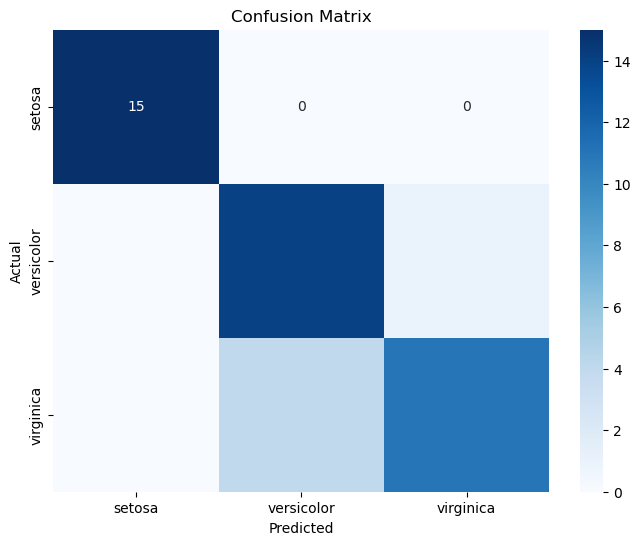



5. Model Interpretation
Feature Importances (from RandomForest within pipeline):
petal width (cm)     0.454892
petal length (cm)    0.400227
sepal length (cm)    0.120608
sepal width (cm)     0.024273
dtype: float64


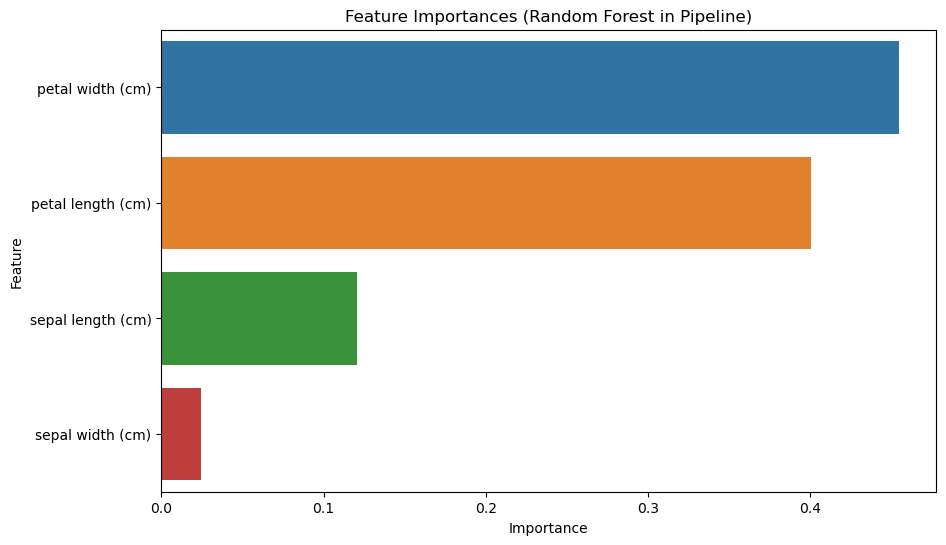


Permutation Importances (on test set, using pipeline):
             feature  importance_mean  importance_std
0  sepal length (cm)        -0.015556        0.014229
1   sepal width (cm)        -0.002222        0.006667
2  petal length (cm)         0.113333        0.030551
3   petal width (cm)         0.162222        0.038554


C:\Users\Han\AppData\Local\Temp\ipykernel_26204\820139096.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


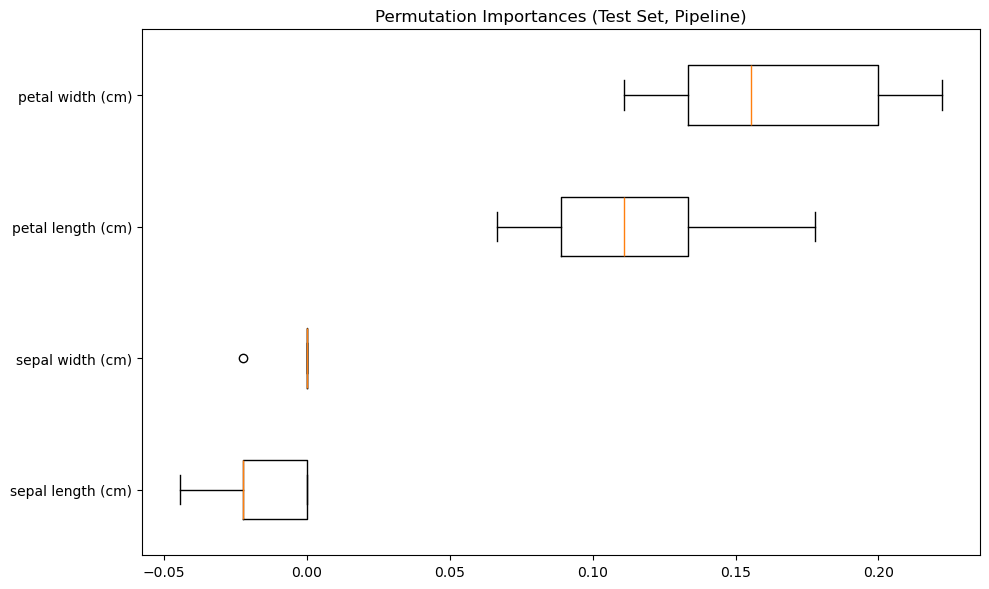


Inspecting a single prediction (Sample Index: 37):
  Features: [[4.7 3.2 1.3 0.2]]
  True Label: setosa
  Predicted Label: setosa
  Prediction Probabilities: {'setosa': 1.0, 'versicolor': 0.0, 'virginica': 0.0}

End of ML pipeline demonstration.


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import make_pipeline # Import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance
import numpy as np

# 1. Data Loading
print("1. Data Loading")
from sklearn.datasets import load_iris
iris = load_iris()
data = pd.DataFrame(data=iris.data, columns=iris.feature_names)
data['target'] = iris.target
data['target_names'] = data['target'].apply(lambda x: iris.target_names[x])

print("First 5 rows of the dataset:")
print(data.head())
print("\nDataset Info:")
data.info()
print("\n")

# 2. Data Preparation (using make_pipeline for preprocessing)
print("2. Data Preparation")

# Separate features (X) and target (y)
X = data.drop(['target', 'target_names'], axis=1)
y = data['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print("\n")

# 3. Model Building (Training) with make_pipeline
print("3. Model Building (Training) with make_pipeline")

# Create a pipeline that first scales the data, then applies the Random Forest Classifier
# make_pipeline automatically names the steps based on their class names (lowercase)
pipeline = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
)

print("Pipeline created:", pipeline)
print("Training the pipeline (which includes scaling and model fitting)...")
pipeline.fit(X_train, y_train) # Pass raw X_train, pipeline handles scaling internally
print("Pipeline training complete.\n")

# 4. Model Evaluation
print("4. Model Evaluation")

# Make predictions on the test set
# The pipeline automatically applies the scaler (fitted on X_train) to X_test before prediction
y_pred = pipeline.predict(X_test)

# Evaluate the model's performance
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\n")

# 5. Model Interpretation
print("5. Model Interpretation")

# Accessing the final model from the pipeline
# The Random Forest Classifier is the last step in our pipeline
final_model = pipeline.named_steps['randomforestclassifier']

# Feature Importance (from RandomForest)
print("Feature Importances (from RandomForest within pipeline):")
feature_importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Feature Importances (Random Forest in Pipeline)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()
#
# Permutation Importance (on test set)
print("\nPermutation Importances (on test set, using pipeline):")
# Permutation importance works directly with the pipeline
result = permutation_importance(pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

perm_importance_df = pd.DataFrame({
    'feature': X.columns[sorted_idx],
    'importance_mean': result.importances_mean[sorted_idx],
    'importance_std': result.importances_std[sorted_idx]
})
print(perm_importance_df)

plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Importances (Test Set, Pipeline)")
plt.tight_layout()
plt.show()

# Example: Inspecting a single prediction
sample_idx = np.random.randint(0, len(X_test))
sample_features = X_test.iloc[[sample_idx]] # Pass raw features to the pipeline
true_label = iris.target_names[y_test.iloc[sample_idx]]
predicted_label_code = pipeline.predict(sample_features)[0] # Pipeline handles scaling
predicted_label = iris.target_names[predicted_label_code]
prediction_probabilities = pipeline.predict_proba(sample_features)[0] # Pipeline handles scaling

print(f"\nInspecting a single prediction (Sample Index: {sample_idx}):")
print(f"  Features: {sample_features.values}")
print(f"  True Label: {true_label}")
print(f"  Predicted Label: {predicted_label}")
print(f"  Prediction Probabilities: {dict(zip(iris.target_names, prediction_probabilities.round(3)))}")

print("\nEnd of ML pipeline demonstration.")